Mean Squared Error: 0.25
R2 Score: 0.51


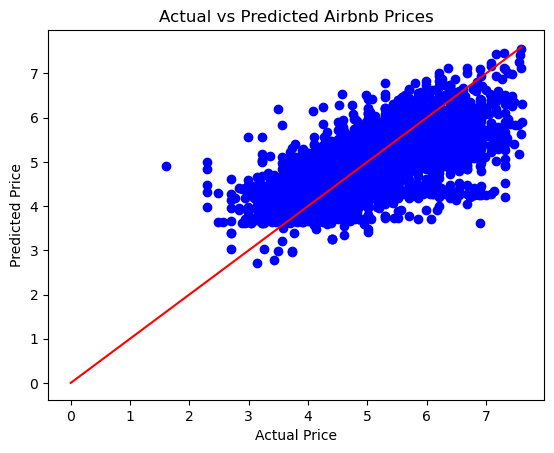

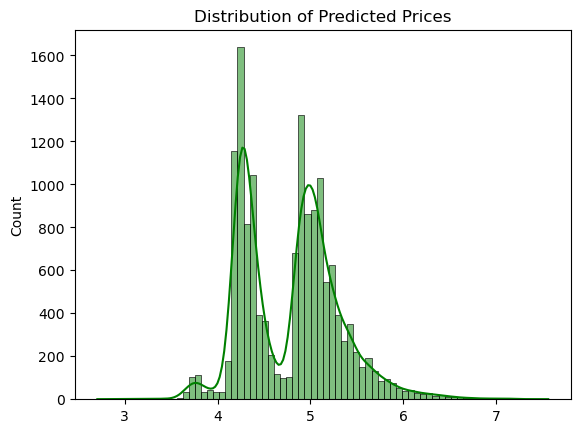

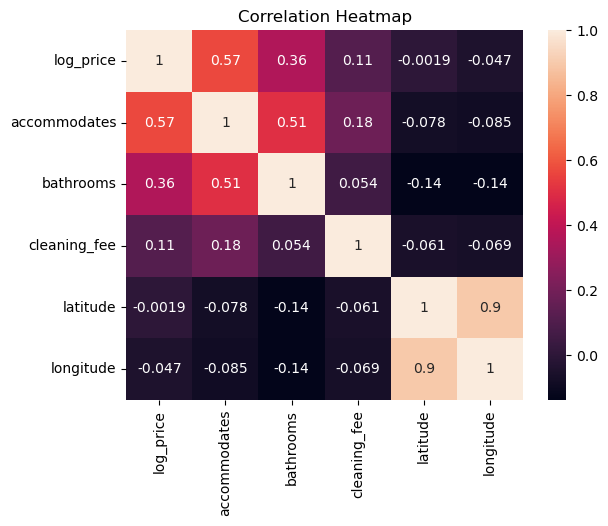

In [10]:
#Major Project
#Project= Airbnb Listing Price based on Location,Property type, and amenities, Dataset
#Name: Sabitha

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("airbnb_data.csv")
df.columns = df.columns.str.strip()
df = df[['log_price', 'property_type', 'room_type', 'accommodates', 'bathrooms','cleaning_fee', 'latitude', 'longitude']]
df = df.dropna()
df = df[df['log_price'] > 0]

df['cleaning_fee'] = df['cleaning_fee'].replace('[\\$,]', '', regex=True)
df = pd.get_dummies(df, columns=['property_type', 'room_type'], drop_first=True)

X = df.drop('log_price', axis=1)
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

plt.scatter(y_test, y_pred, color='blue')
plt.plot([0, max(y_test)], [0, max(y_test)], color='red')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")
plt.show()

sns.histplot(y_pred, kde=True, color='green')
plt.title("Distribution of Predicted Prices")
plt.show()

numeric_cols = ['log_price', 'accommodates', 'bathrooms','cleaning_fee', 'latitude', 'longitude']
sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Conclusion:** 

I predicted Airbnb prices using property type, room type, accommodates, bathrooms, cleaning fee, latitude, and longitude.

Linear Regression showed reasonable performance, and visualizations helped analyze predictions and feature correlations. 

This project demonstrates the ability to clean data, handle categorical features, and build a simple predictive model.